# Compare parameter estimation via stepwise BFGS with evofr

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import evofr as ef

from viral_variant_comp.simulate_count_data import create_count_data, convert_count_data_to_df, prepare_count_data_evofr
from viral_variant_comp.plotting import plot_viral_composition_dual, plot_confidence_intervals, plot_heatmap, plot_confidence_intervals_deviation
from viral_variant_comp.estimate import evaluate_result, reorder_variants, calculateHessian, calculate_cooccurence
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator, EvofrCompositionEstimator


/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


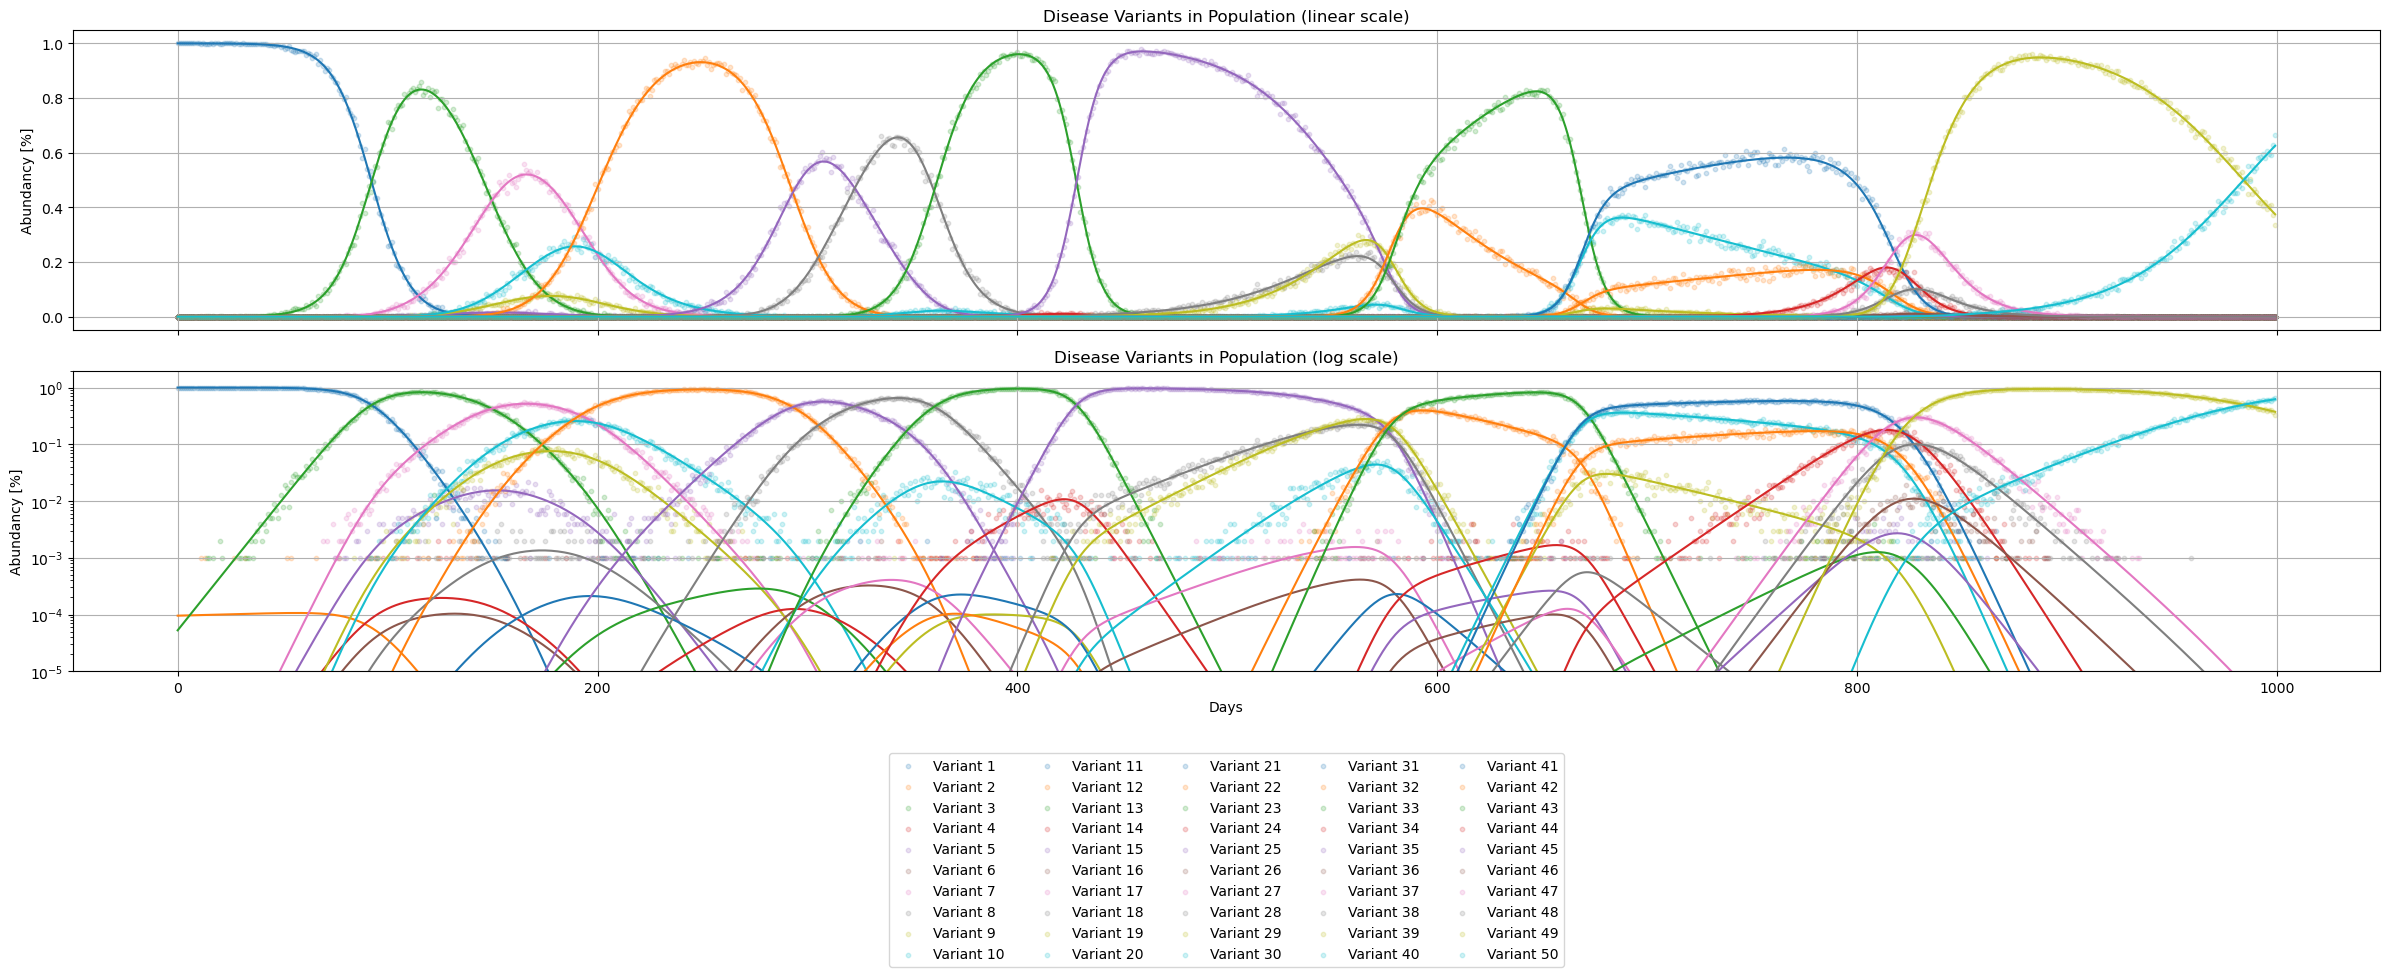

In [3]:
n_variants = 50
n_days = 1000
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0, reorder=True)
plot_viral_composition_dual(data['counts'], data['freq'], y_range = (1e-5, 2))

#np.savez('data/simulated_counts/counts_50var_1000days_1000samples.npz', **data)

## Use Evofr to estimate variant parameters
Evofr offers two main methods to estimate growth rate and log initial frequency from variant count data:
- MCMC sampling to approximate full posterior
    - implemented with inference method InferNUTS
- SVI (stochastic variational inference) to approximate MAP estimate
    - faster than MCMC
    - implemented with inference method InferMAP

In [4]:
estimator_evofr = EvofrCompositionEstimator(data['counts'])
estimator_evofr.fit()
result_evofr = estimator_evofr.get_results()

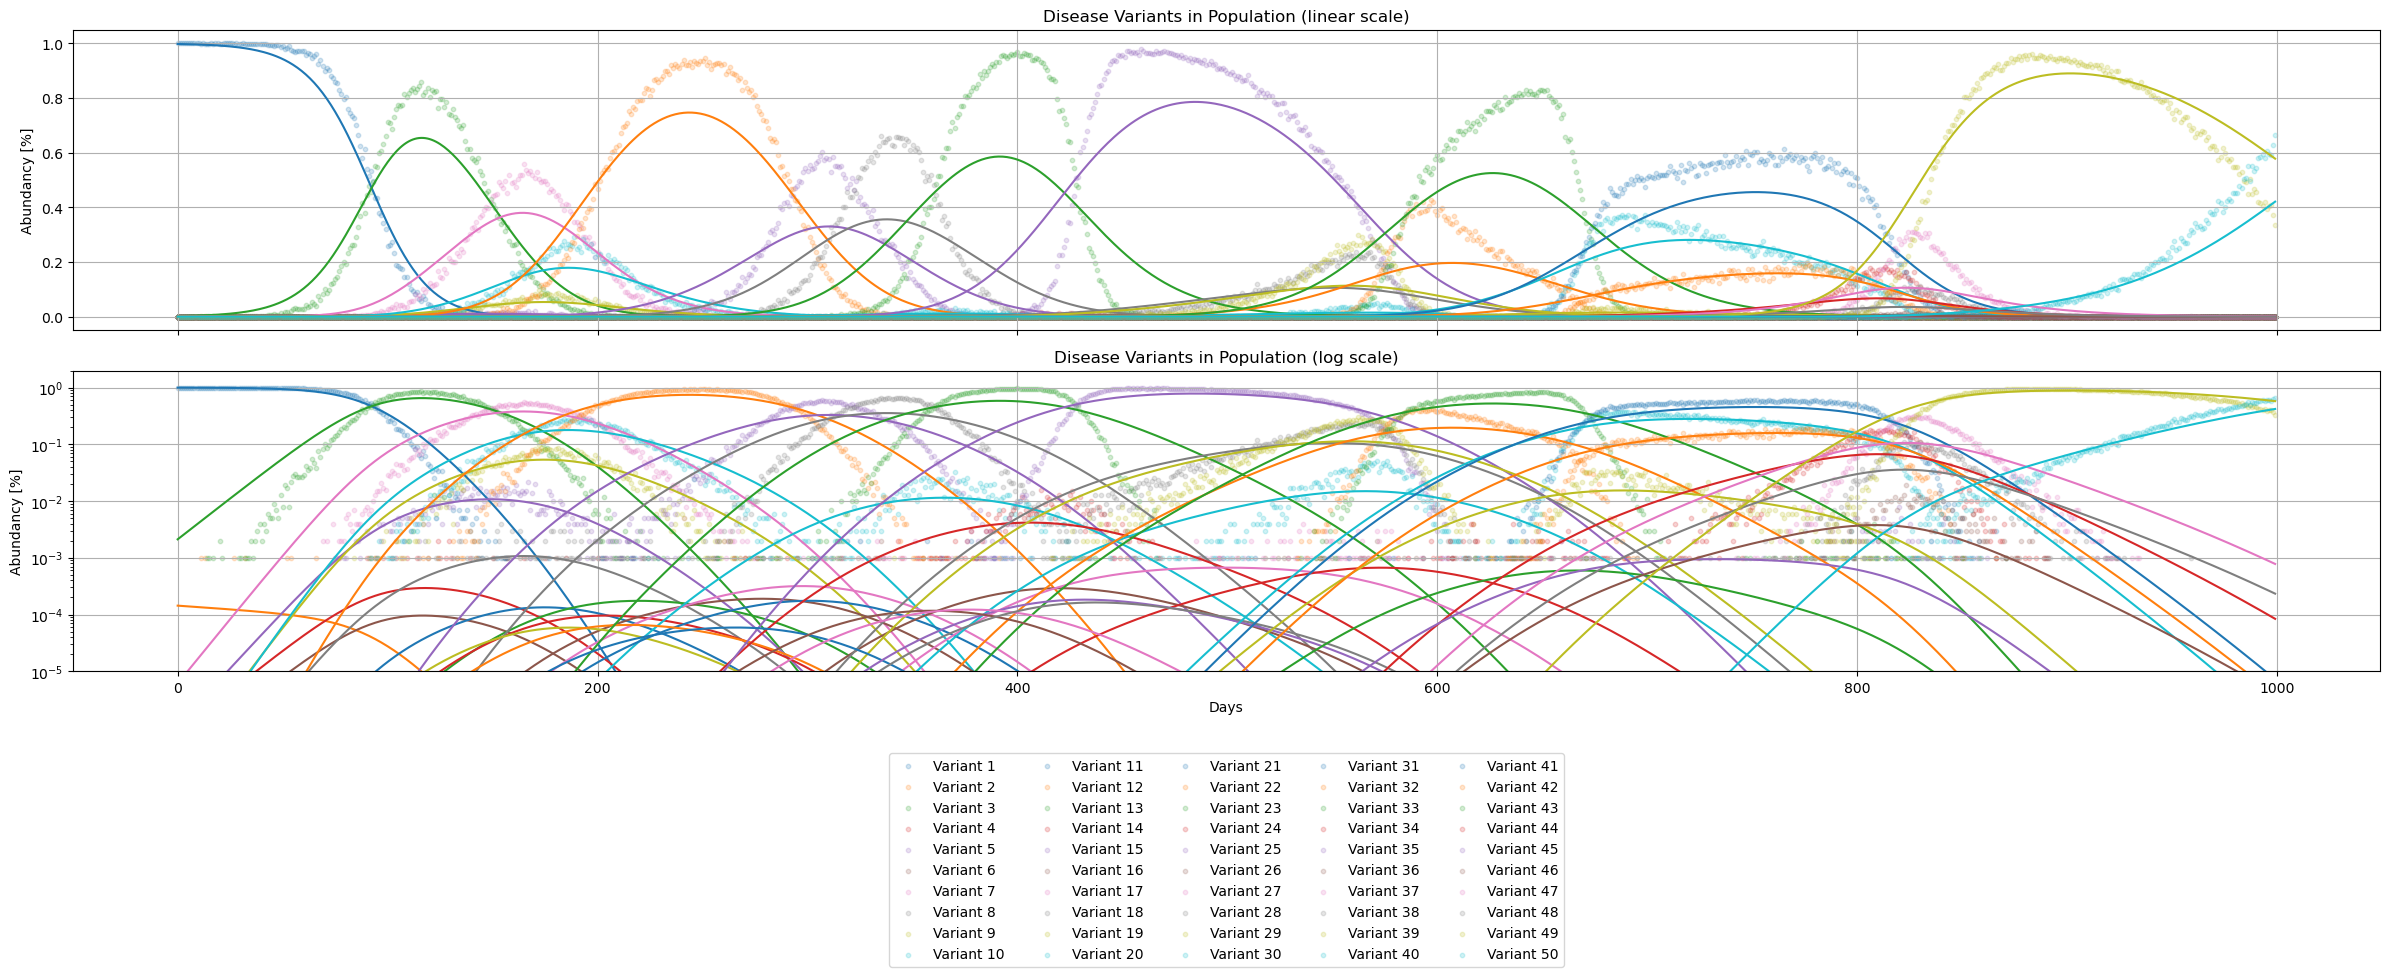

(100,)


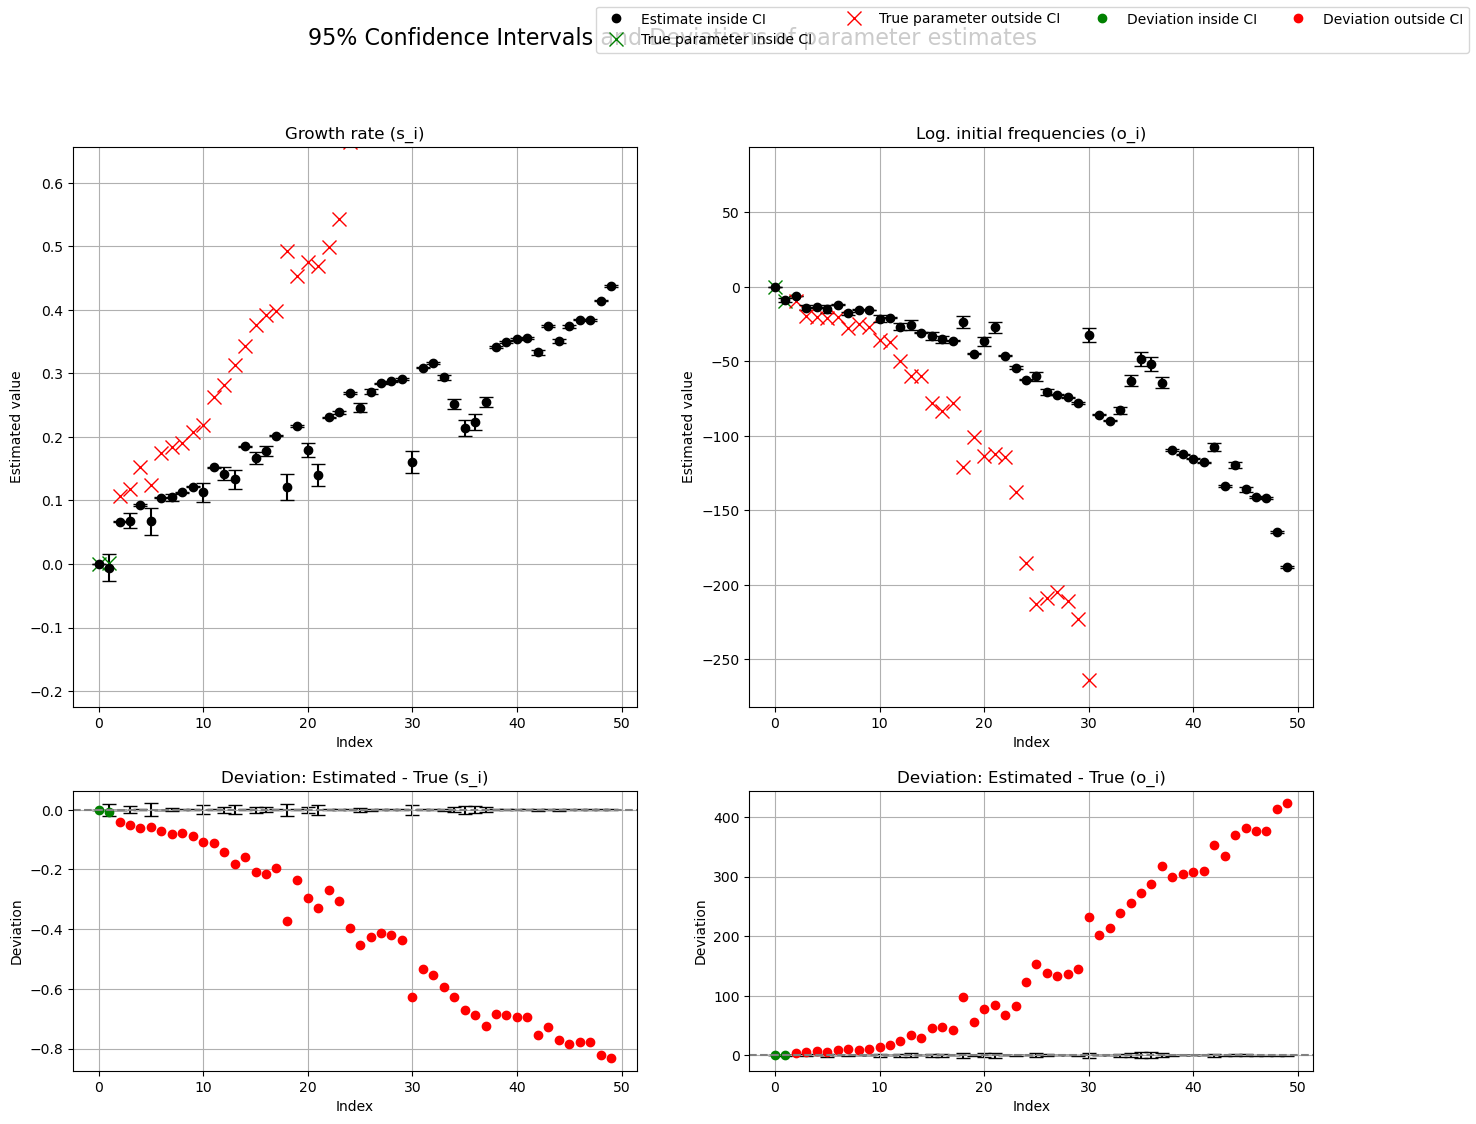

In [5]:
plot_viral_composition_dual(data['counts'], result_evofr['composition_estimate'], y_range = (1e-5, 2))

df = evaluate_result(result_evofr['growth_rate_estimate'], result_evofr['log_init_freq_estimate'], result_evofr['hess_inv'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df)

In [5]:
# reload data and posterior

#data = np.load('data/data_50var_1000days_1000samples.npz')
#variant_frequencies = ef.VariantFrequencies(data['counts'], pivot="variant_0")
#posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

## Compare to BFGS optimization

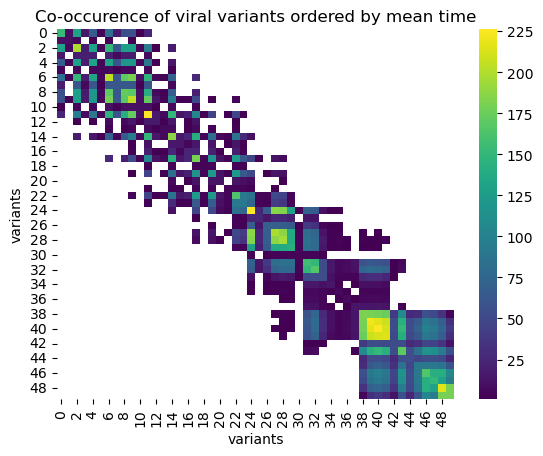

In [6]:
co_occurence_reorderd = calculate_cooccurence(data['counts'])
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

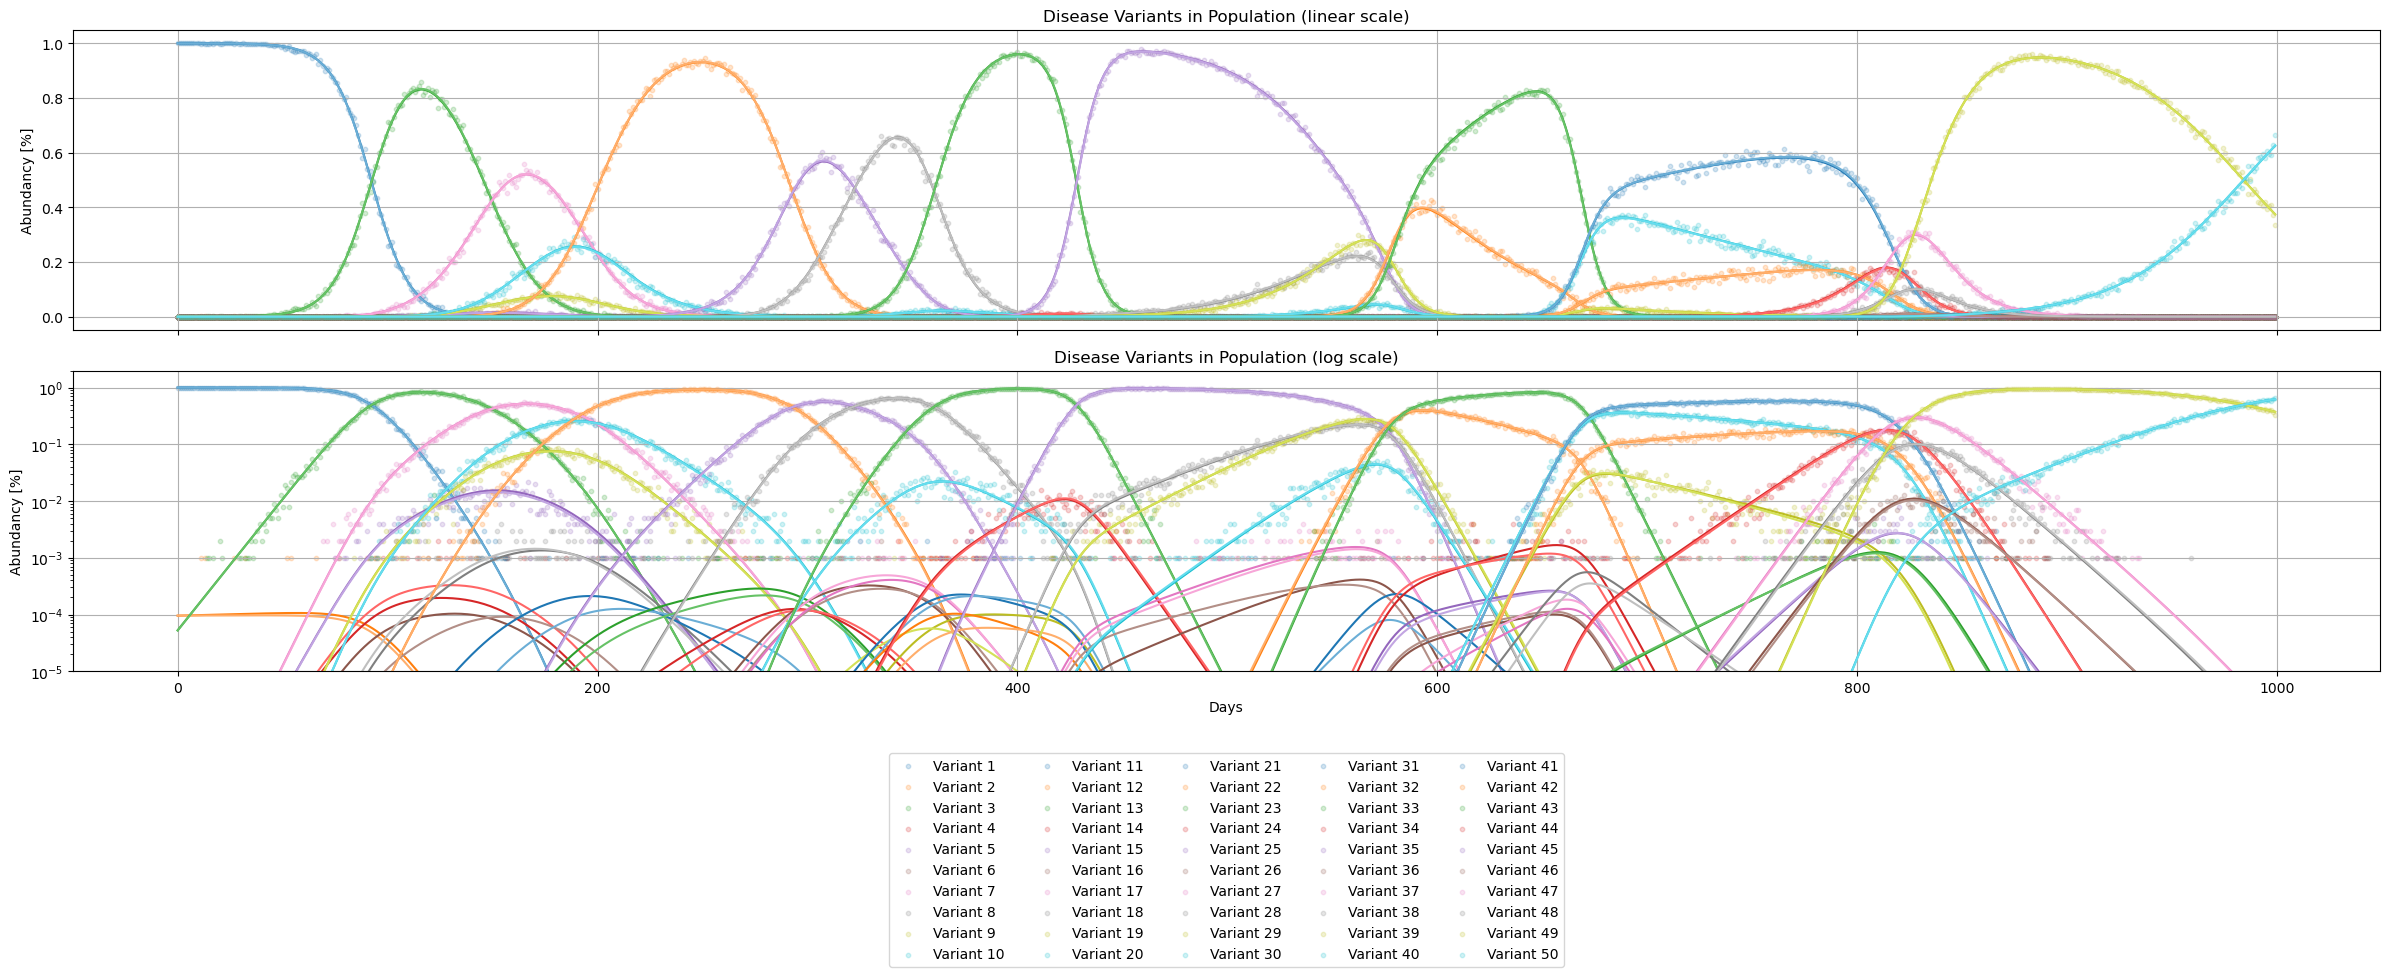

In [7]:
partition_size = 10
overlap_size = 4

estimator_stepwise = StepwiseBFGSCompositionEstimator(data['counts'], partition_size, overlap_size)
estimator_stepwise.fit()
result_stepwise = estimator_stepwise.get_results()

plot_viral_composition_dual(data['counts'], data['freq'], result_stepwise['composition_estimate'], y_range = (1e-5, 2))

(100,)


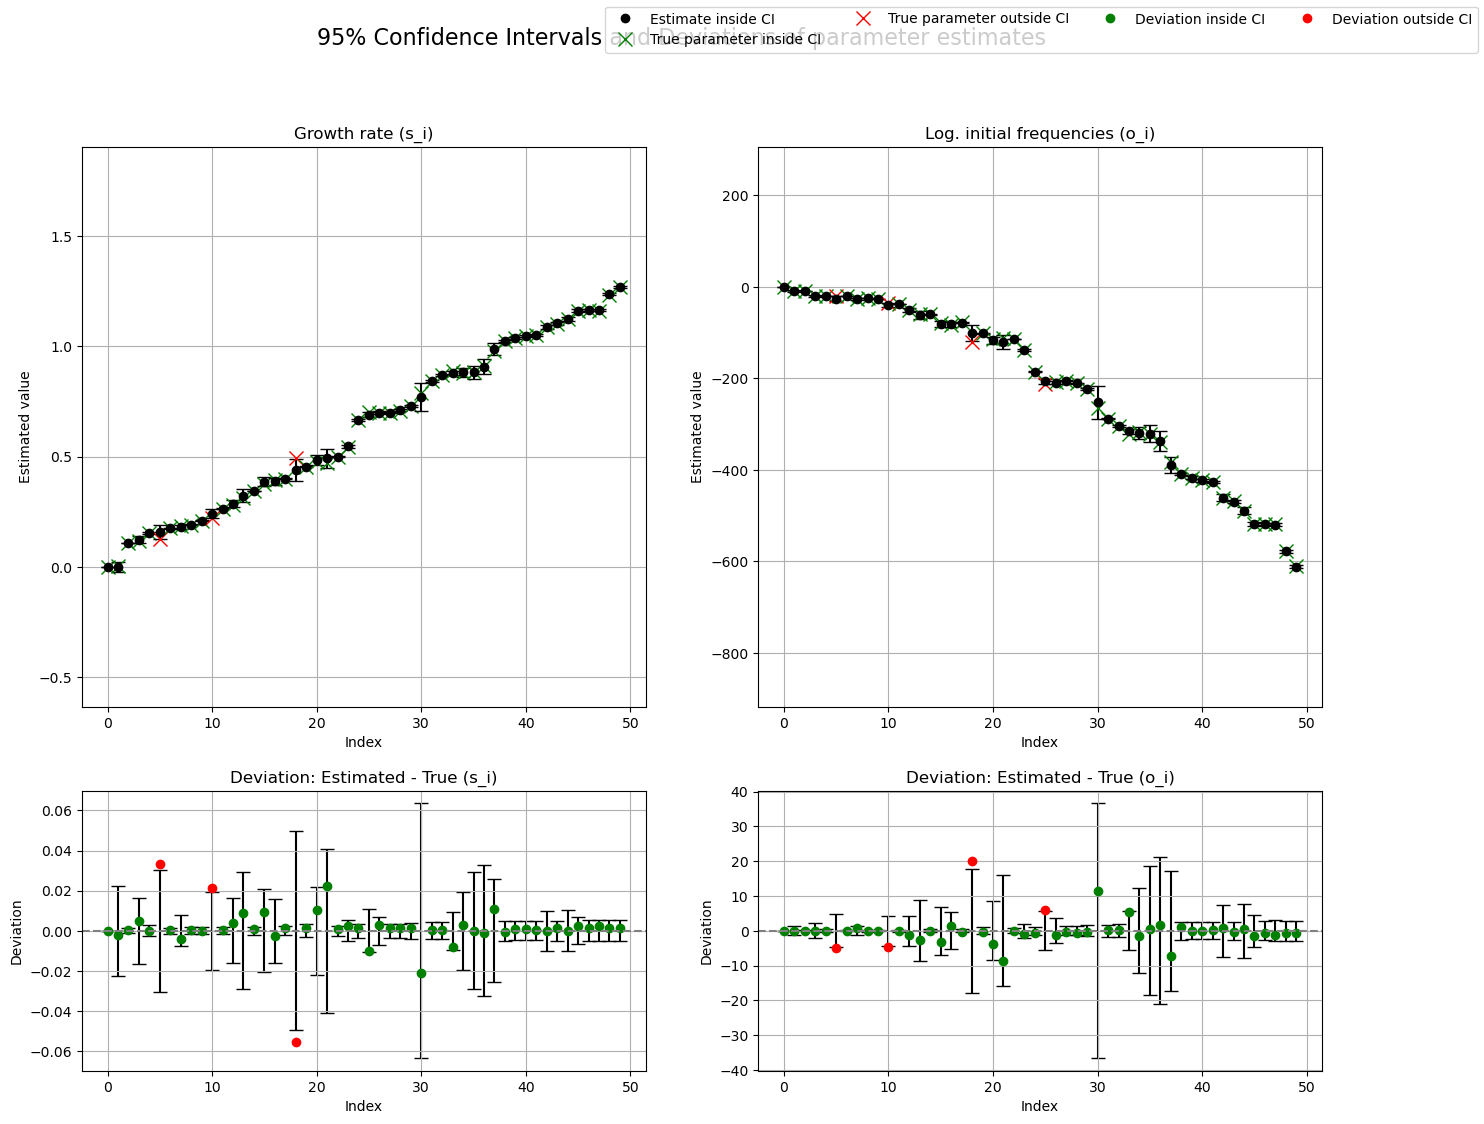

In [8]:
df_bfgs = evaluate_result(result_stepwise['growth_rate_estimate'], result_stepwise['log_init_freq_estimate'], result_stepwise['hess_inv'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df_bfgs)

### Trial with their data

In [9]:
#posterior.save_posterior("data/mlr_estimates.pkl")
# Loading new posterior
#loaded_posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from evofr.plotting import FrequencyPlot, add_dates_sep

In [11]:
counts_df_test = pd.read_csv("../evofr/test/testing_data/mlr-variant-counts.tsv", sep = "\t")

count_matrix = counts_df_test.pivot_table(
    index='date',
    columns='variant',
    values='sequences',
    aggfunc='sum',
    fill_value=0
)
counts_array = count_matrix.to_numpy()
counts_array.shape

#composition_estimate = calculate_frequencies(counts_array.shape[0], s_vec, o_vec) #maybe log scale


(70, 3)

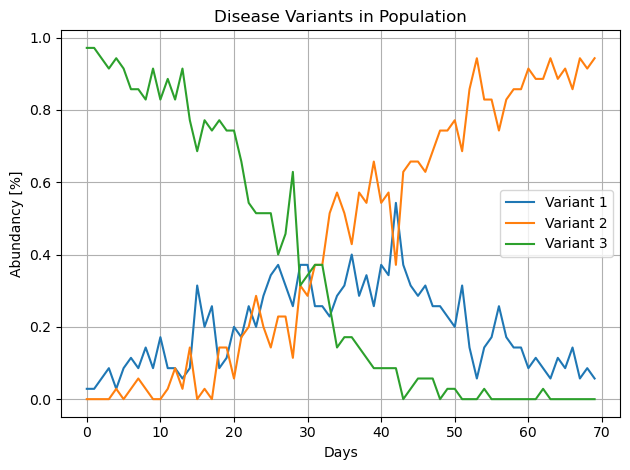

In [12]:
# Plot each variant
def plot_variants(counts):

    day_sums = np.sum(counts, axis = 1)

    for i in range(counts.shape[1]):
        plt.plot(np.arange(counts.shape[0]), counts[:, i] / day_sums[i], label = f'Variant {i+1}') 

    plt.xlabel("Days")
    plt.ylabel("Abundancy [%]")
    plt.title("Disease Variants in Population")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_variants(counts_array)


In [13]:
variant_frequencies = ef.VariantFrequencies(counts_df_test, pivot="variant_0")

mlr = ef.MultinomialLogisticRegression(tau=1) # tau: average generation time (1 day)
#inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in
inference_method = ef.InferMAP(iters = 10000, lr = 4e-3)


posterior_test = inference_method.fit(mlr, variant_frequencies)

forecast_L = 50
posterior_test.samples = mlr.forecast_frequencies(posterior_test.samples, forecast_L)

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/evofr/data/data_helpers.py:90: UserWarning: variant_0 not present in variant names. Using provided order.
  warnings.warn(f"{pivot} not present in variant names. Using provided order.")


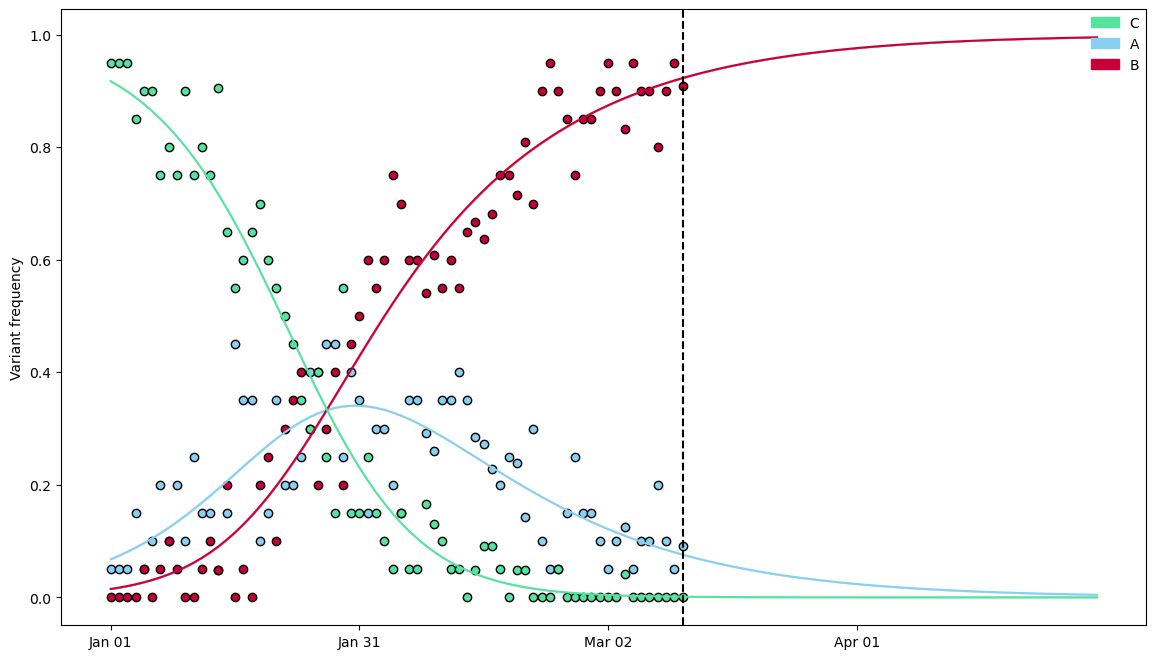

In [14]:
v_colors = ["#56e39f", "#89CFF0", "#C70039"]
v_names = list(counts_df_test.variant.unique())
color_map = {v: c for c, v in zip(v_colors, v_names)}

# Plot predicted frequencies
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(nrows=1, ncols=1)
ax = fig.add_subplot(gs[0,0])

FrequencyPlot(posterior_test, color_map=color_map).plot(ax, forecast=True)
ax.axvline(x=len(variant_frequencies.dates)-1, color='k', linestyle='--') # Adding forecast cut off
add_dates_sep(ax, ef.data.expand_dates(variant_frequencies.dates, forecast_L), sep=30) # Adding dates

ax.legend(
    handles=[
        mpatches.Patch(color=c, label=v) for v, c in color_map.items()
    ],
    loc='upper right',
    fontsize=10,
    frameon=False,
    ncol=1,  # single column
    borderaxespad=0.1
)